In [72]:
#Aviation & Travel Demand Analytics

In [2]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


plt.style.use("seaborn-v0_8")
sns.set_palette("deep")
import warnings
warnings.simplefilter(action='ignore')
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
#Load the Dataset
df = pd.read_excel("goibibo_flights_data.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: 'goibibo_flights_data.xlsx'

In [182]:
# Display first 5 records
df.head()

,flight date,airline,flight_num,class,from,dep_time,to,arr_time,duration,price,stops
0,26-06-2023,SpiceJet,SG-8709,economy,Delhi,18:55:00,Mumbai,21:05:00,02h 10m,6013,non-stop
1,26-06-2023,SpiceJet,SG-8157,economy,Delhi,06:20:00,Mumbai,08:40:00,02h 20m,6013,non-stop
2,26-06-2023,AirAsia,I5-764,economy,Delhi,04:25:00,Mumbai,06:35:00,02h 10m,6016,non-stop
3,26-06-2023,Vistara,UK-995,economy,Delhi,10:20:00,Mumbai,12:35:00,02h 15m,6015,non-stop
4,26-06-2023,Vistara,UK-963,economy,Delhi,08:50:00,Mumbai,11:10:00,02h 20m,6015,non-stop


In [183]:
#Dataset Dimensions,Structure & Data Types
print("Rows and Columns:", df.shape)
print(df.info())

Rows and Columns: (300261, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300261 entries, 0 to 300260
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   flight date  300261 non-null  object
 1   airline      300261 non-null  object
 2   flight_num   300261 non-null  object
 3   class        300261 non-null  object
 4   from         300261 non-null  object
 5   dep_time     300261 non-null  object
 6   to           300261 non-null  object
 7   arr_time     300261 non-null  object
 8   duration     300261 non-null  object
 9   price        300261 non-null  object
 10  stops        300261 non-null  object
dtypes: object(11)
memory usage: 25.2+ MB
None


In [184]:
#checking missing values
print("Missing values per column:")
missing_values=df.isnull().sum()
print(missing_values)
if missing_values.sum() == 0:
    print("\n No missing values found. Data quality is good.")
else:
    print("\n Missing values detected. Data cleaning required.")

Missing values per column:
flight date    0
airline        0
flight_num     0
class          0
from           0
dep_time       0
to             0
arr_time       0
duration       0
price          0
stops          0
dtype: int64

 No missing values found. Data quality is good.


In [185]:
#Check Duplicates

#checking duplicacy if any
duplicate_count = df.duplicated().sum()
print("Total Duplicate Rows:", duplicate_count)

if duplicate_count > 0:
    print("\nDuplicate Rows:")
    display(df[df.duplicated(keep=False)])
else:
    print("No duplicates found.")


Total Duplicate Rows: 2

Duplicate Rows:


,flight date,airline,flight_num,class,from,dep_time,to,arr_time,duration,price,stops
516,29-06-2023,Air India,AI-807,economy,Delhi,17:20:00,Mumbai,08:35:00,15h 15m,12272,1-stop
563,29-06-2023,Air India,AI-807,economy,Delhi,17:20:00,Mumbai,08:35:00,15h 15m,12272,1-stop
6080,26-07-2023,Air India,AI-475,economy,Delhi,13:00:00,Mumbai,13:35:00,24h 35m,4828,1-stop
6181,26-07-2023,Air India,AI-475,economy,Delhi,13:00:00,Mumbai,13:35:00,24h 35m,4828,1-stop


In [186]:
#remove duplicates rows
df = df.drop_duplicates()
print("Duplicates rows are removed")

Duplicates rows are removed


In [187]:
#Clean Columns Names
df.columns = df.columns.str.lower().str.replace(" ", "_")
print("Columns cleaned")


Columns cleaned


In [190]:
#Checking "duration" column
df['duration'].head()

0    02h 10m
1    02h 20m
2    02h 10m
3    02h 15m
4    02h 20m
Name: duration, dtype: object

In [191]:
#convert "duration" which is in (hr&min) to min
df['duration'] = df['duration'].astype(str)

hours = df['duration'].str.extract(r'(\d+)h')[0].astype(float).fillna(0)
minutes = df['duration'].str.extract(r'(\d+)m')[0].astype(float).fillna(0)

df['duration_min'] = hours * 60 + minutes

In [192]:
#Drop old column "duration"
df.drop(columns=['duration'], inplace=True)

In [193]:
#Checking new column "duration_min" for verifying and checking datatypes also
print(df[['duration_min']].head())

#checking data types
df.dtypes


   duration_min
0         130.0
1         140.0
2         130.0
3         135.0
4         140.0


flight_date      object
airline          object
flight_num       object
class            object
from             object
dep_time         object
to               object
arr_time         object
price            object
stops            object
duration_min    float64
dtype: object

In [194]:
#Checking "stops" column
df['stops'].head(30)

0                                              non-stop
1                                              non-stop
2                                              non-stop
3                                              non-stop
4                                              non-stop
5                                              non-stop
6                                              non-stop
7                                              non-stop
8                                              non-stop
9                                              non-stop
10                                             non-stop
11                                             non-stop
12                                             non-stop
13                                             non-stop
14                                             non-stop
15                                             non-stop
16                                             non-stop
17                                             n

In [195]:
#Clean & Extract Number of "stops"

# Convert to lowercase and remove extra spaces
df['stops'] = df['stops'].str.lower().str.strip()

# Replace 'non-stop' with 0
df['stops'] = df['stops'].replace('non-stop', '0')

# Extract the number of stops
df['stops'] = df['stops'].str.extract(r'(\d+)').astype(int)

In [197]:
#Checking "stops" colum for verifying
print(df['stops'].head(5))
print(df['stops'].value_counts())
df.head()

0    0
1    0
2    0
3    0
4    0
Name: stops, dtype: int64
stops
1    250927
0     36044
2     13288
Name: count, dtype: int64


,flight_date,airline,flight_num,class,from,dep_time,to,arr_time,price,stops,duration_min
0,26-06-2023,SpiceJet,SG-8709,economy,Delhi,18:55:00,Mumbai,21:05:00,6013,0,130.0
1,26-06-2023,SpiceJet,SG-8157,economy,Delhi,06:20:00,Mumbai,08:40:00,6013,0,140.0
2,26-06-2023,AirAsia,I5-764,economy,Delhi,04:25:00,Mumbai,06:35:00,6016,0,130.0
3,26-06-2023,Vistara,UK-995,economy,Delhi,10:20:00,Mumbai,12:35:00,6015,0,135.0
4,26-06-2023,Vistara,UK-963,economy,Delhi,08:50:00,Mumbai,11:10:00,6015,0,140.0


In [198]:
#Converting Data Types which are required

# Convert "flight_date" to datetime
df['flight_date'] = pd.to_datetime(df['flight_date'], errors='coerce')
print("flight_date converted to datetime")

#Convert "price" to numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')
print("price converted to numeric")


flight_date converted to datetime
price converted to numeric


In [199]:
#Final data types verification
df.dtypes

flight_date     datetime64[ns]
airline                 object
flight_num              object
class                   object
from                    object
dep_time                object
to                      object
arr_time                object
price                  float64
stops                    int64
duration_min           float64
dtype: object

price               0
stops           49332
duration_min     2004
dtype: int64


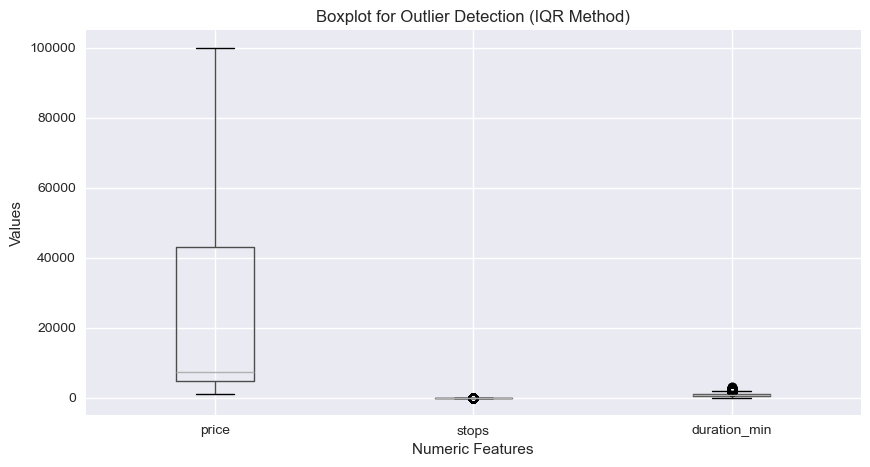

In [200]:
# Checking Outliers if any and treating them (if any)
numeric_df = df.select_dtypes(include='number')
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Count outliers per column
print((numeric_df < lower).sum() + (numeric_df > upper).sum())

#By Boxplot
plt.figure(figsize=(10,5))
numeric_df.boxplot()
plt.title("Boxplot for Outlier Detection (IQR Method)")
plt.xlabel("Numeric Features")
plt.ylabel("Values")
plt.show()

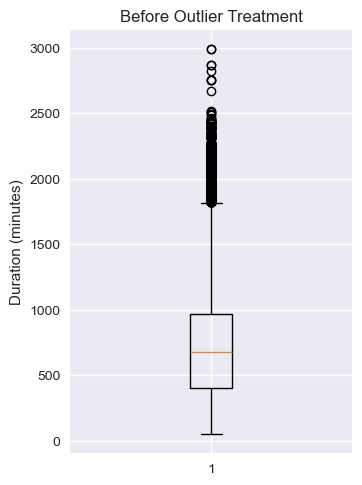

In [91]:
#boxplot for "duration_min"
plt.subplot(1, 2, 1)
plt.boxplot(df['duration_min'])
plt.title("Before Outlier Treatment")
plt.ylabel("Duration (minutes)")
plt.show()
#copy the values
df['duration_min_before'] = df['duration_min'].copy()

In [201]:
#Outliers treatment for "duration_min"
Q1 = df['duration_min'].quantile(0.25)
Q3 = df['duration_min'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df.loc[df['duration_min'] < lower_limit, 'duration_min'] = lower_limit
df.loc[df['duration_min'] > upper_limit, 'duration_min'] = upper_limit
#Checking Outliers for "duration_min"
print(
    ((df['duration_min'] < lower_limit) | 
     (df['duration_min'] > upper_limit)).sum()
)


0


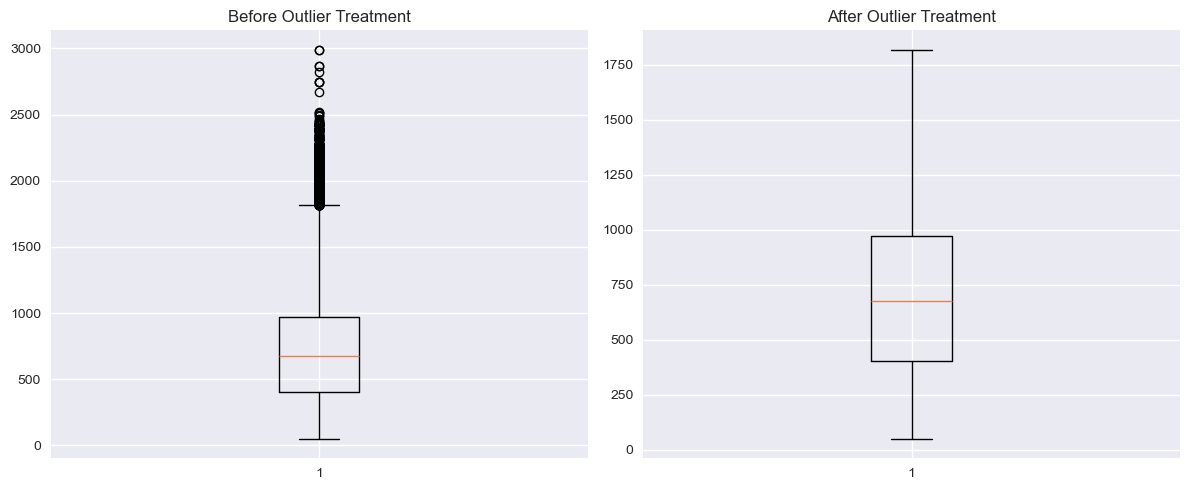

In [93]:
#Checking throught Boxplot before and after
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.boxplot(df['duration_min_before'])
plt.title("Before Outlier Treatment")

plt.subplot(1, 2, 2)
plt.boxplot(df['duration_min'])
plt.title("After Outlier Treatment")

plt.tight_layout()
plt.show()

In [202]:
#Extracting Date,Month and Year from "flight_date"
df['year'] = df['flight_date'].dt.year
df['month'] = df['flight_date'].dt.month
df['day'] = df['flight_date'].dt.day

In [203]:
#Filtering flights details by "price">5000
df[df['price'] > 5000].head()

,flight_date,airline,flight_num,class,from,dep_time,to,arr_time,price,stops,duration_min,year,month,day
0,2023-06-26,SpiceJet,SG-8709,economy,Delhi,18:55:00,Mumbai,21:05:00,6013.0,0,130.0,2023,6,26
1,2023-06-26,SpiceJet,SG-8157,economy,Delhi,06:20:00,Mumbai,08:40:00,6013.0,0,140.0,2023,6,26
2,2023-06-26,AirAsia,I5-764,economy,Delhi,04:25:00,Mumbai,06:35:00,6016.0,0,130.0,2023,6,26
3,2023-06-26,Vistara,UK-995,economy,Delhi,10:20:00,Mumbai,12:35:00,6015.0,0,135.0,2023,6,26
4,2023-06-26,Vistara,UK-963,economy,Delhi,08:50:00,Mumbai,11:10:00,6015.0,0,140.0,2023,6,26


In [204]:
df.dtypes

flight_date     datetime64[ns]
airline                 object
flight_num              object
class                   object
from                    object
dep_time                object
to                      object
arr_time                object
price                  float64
stops                    int64
duration_min           float64
year                     int32
month                    int32
day                      int32
dtype: object

In [205]:
#Grouping & Aggregation

#find the mean price value according to the airlines
print(df.groupby('airline')['price'].mean().sort_values())
#find the mean price value according to the stops(0,1,2)
print(df.groupby('stops')['price'].mean())
#find the mean price value according to the months of year data'2023'
(df.groupby('month')['price'].mean())

airline
Trujet        3277.097561
AirAsia       4132.026525
StarAir       4982.016393
Indigo        5377.492092
GO FIRST      5708.459464
SpiceJet      6241.051826
Air India    23837.936075
Vistara      30755.022172
Name: price, dtype: float64
stops
0     9493.462879
1    23183.801742
2    14080.437288
Name: price, dtype: float64


month
1     22299.037243
2     22723.900885
3     22177.747573
4     22497.249754
5     22534.021635
6     24925.329684
7     19956.250899
8     20464.297947
9     21208.208149
10    20918.564800
11    19799.345344
12    19929.857406
Name: price, dtype: float64

In [207]:
#Saving our cleaned dataset
df.to_csv("cleaned_goibibo_flights_data.csv", index=False)
print("Cleaned data Saved Successfully")

Cleaned data Saved Successfully


In [208]:
#Descriptive Statistics
df.describe()

,flight_date,price,stops,duration_min,year,month,day
count,300259,300128.000000,300259.000000,300259.000000,300259.0,300259.000000,300259.000000
mean,2023-07-06 18:53:17.999060736,21137.487892,0.924212,731.845673,2023.0,6.716828,15.007787
min,2023-01-07 00:00:00,1116.000000,0.000000,50.000000,2023.0,1.000000,7.000000
25%,2023-06-26 00:00:00,4831.000000,1.000000,405.000000,2023.0,6.000000,8.000000
50%,2023-07-19 00:00:00,7499.000000,1.000000,675.000000,2023.0,7.000000,13.000000
75%,2023-07-31 00:00:00,43159.000000,1.000000,970.000000,2023.0,7.000000,23.000000
max,2023-12-08 00:00:00,99942.000000,2.000000,1817.500000,2023.0,12.000000,31.000000
std,NaN,22985.350778,0.398189,428.050684,0.0,2.451239,8.544635


In [209]:
#Finding Mean,Median & Mode
print("Mean:\n", df.mean(numeric_only=True))
print("\nMedian:\n", df.median(numeric_only=True))
print("\nMode:\n", df.mode().iloc[0])

Mean:
 price           21137.487892
stops               0.924212
duration_min      731.845673
year             2023.000000
month               6.716828
day                15.007787
dtype: float64

Median:
 price           7499.0
stops              1.0
duration_min     675.0
year            2023.0
month              7.0
day               13.0
dtype: float64

Mode:
 flight_date     2023-07-20 00:00:00
airline                     Vistara
flight_num                   UK-706
class                       economy
from                          Delhi
dep_time                   07:00:00
to                           Mumbai
arr_time                   19:55:00
price                       55427.0
stops                             1
duration_min                  130.0
year                           2023
month                             7
day                               8
Name: 0, dtype: object


In [210]:
#Creating frequency table
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


airline value counts:
airline
Vistara      127859
Air India     80892
Indigo        43120
GO FIRST      23177
AirAsia       16098
SpiceJet       9011
StarAir          61
Trujet           41
Name: count, dtype: int64

flight_num value counts:
flight_num
UK-706     3235
UK-772     2741
UK-720     2650
UK-836     2542
UK-822     2468
           ... 
SG-8913       1
SG-1058       1
SG-8480       1
SG-8106       1
I5-737        1
Name: count, Length: 1569, dtype: int64

class value counts:
class
economy     206772
business     93487
Name: count, dtype: int64

from value counts:
from
Delhi        61343
Mumbai       60903
Bangalore    52106
Kolkata      46347
Hyderabad    40860
Chennai      38700
Name: count, dtype: int64

dep_time value counts:
dep_time
07:00:00    8760
10:25:00    7693
19:00:00    5738
09:45:00    5468
08:30:00    4955
            ... 
22:05:00      18
03:30:00      18
00:15:00      15
00:45:00      12
04:15:00       5
Name: count, Length: 251, dtype: int64

to value count

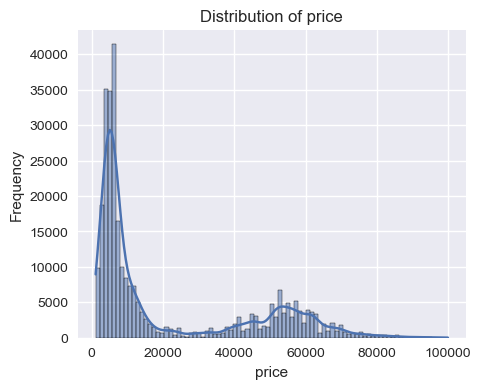

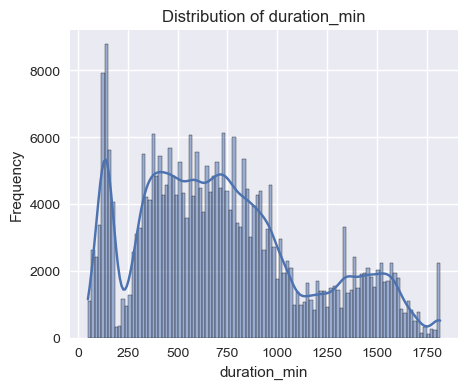

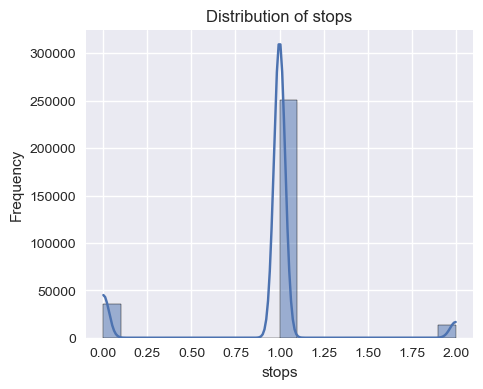

In [211]:
#Distribution Plot
dist_cols = ['price', 'duration_min', 'stops']

for col in dist_cols:
    plt.figure(figsize=(5,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

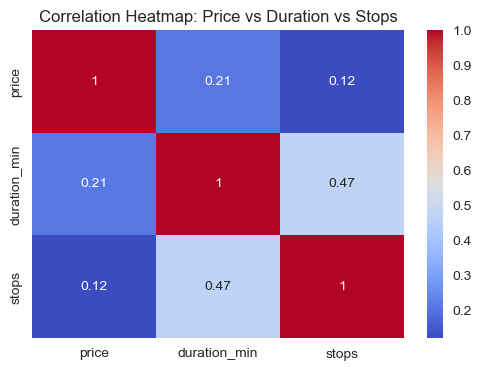

In [212]:
#Coorelation Heatmap
# Select required numeric columns
corr_cols = df[['price', 'duration_min', 'stops']]

# Compute correlation matrix
corr_matrix = corr_cols.corr()

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap: Price vs Duration vs Stops")
plt.show()

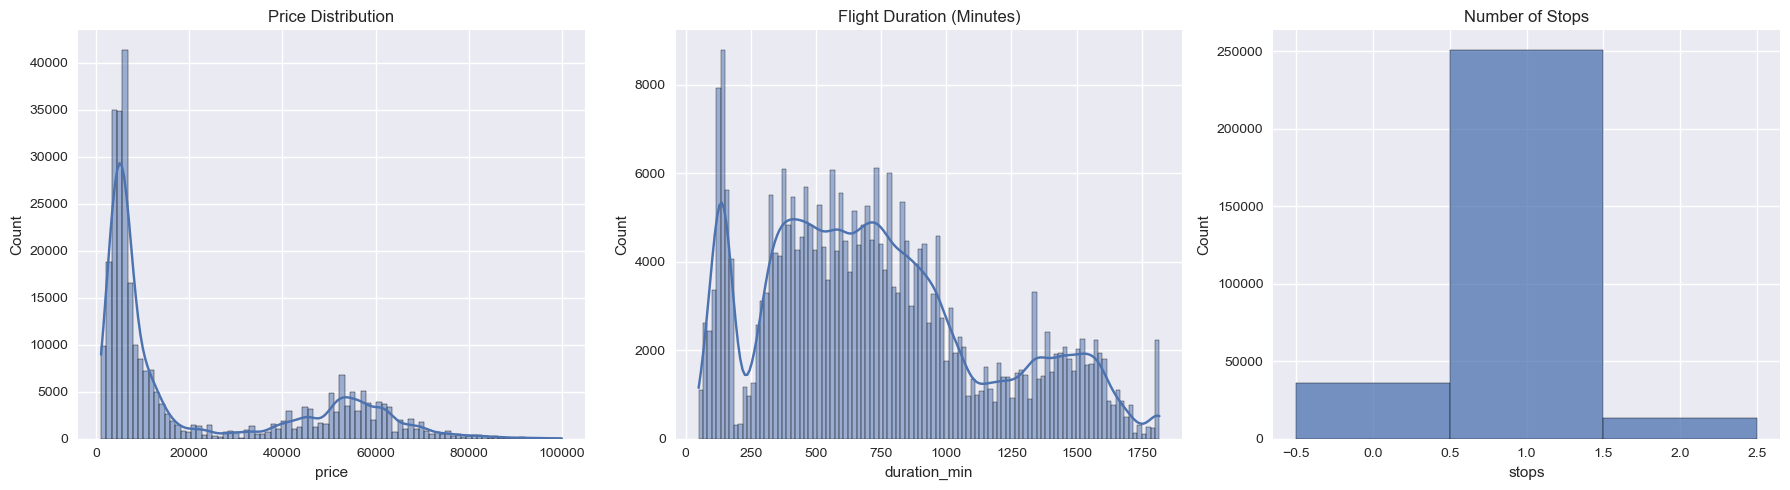

In [213]:
#Exploratory Data Analysis(EDA)

#Univariate
#Distribution Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['price'], kde=True, ax=axes[0])
axes[0].set_title("Price Distribution")

sns.histplot(df['duration_min'], kde=True, ax=axes[1])
axes[1].set_title("Flight Duration (Minutes)")

sns.histplot(df['stops'], discrete=True, ax=axes[2])
axes[2].set_title("Number of Stops")

plt.tight_layout()
plt.show()


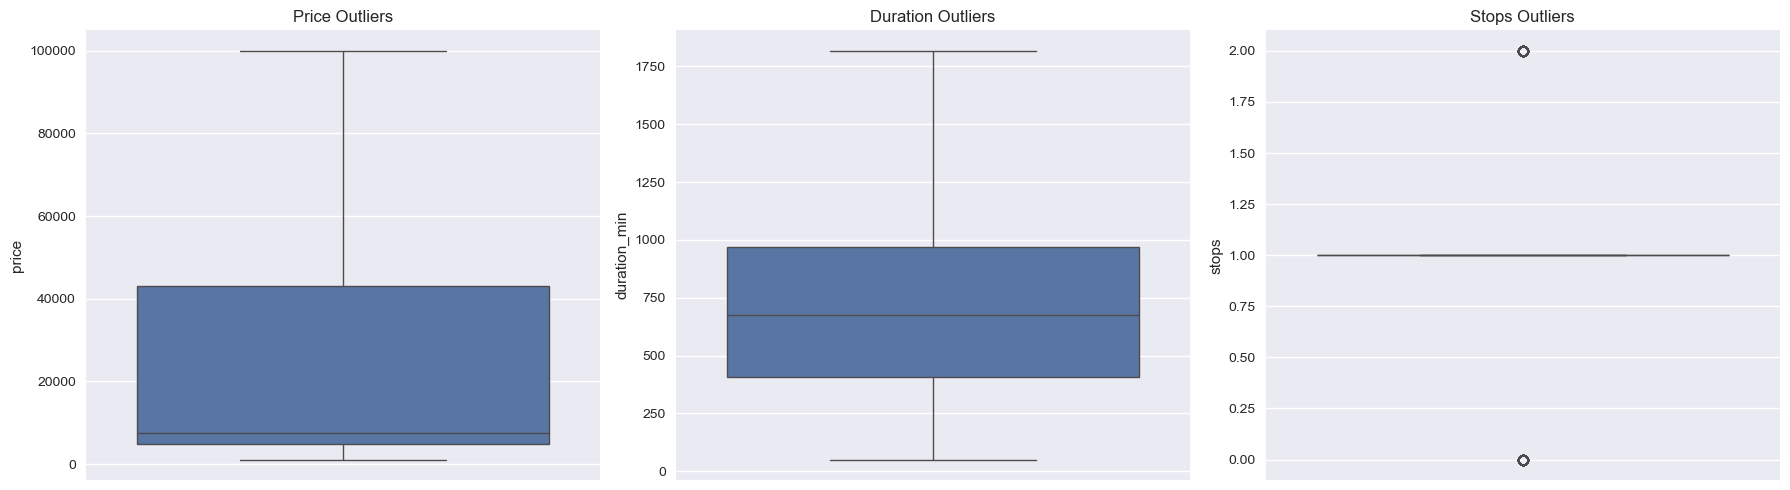

In [214]:
#Boxplots for Outlier Detection
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df['price'], ax=axes[0])
axes[0].set_title("Price Outliers")

sns.boxplot(y=df['duration_min'], ax=axes[1])
axes[1].set_title("Duration Outliers")

sns.boxplot(y=df['stops'], ax=axes[2])
axes[2].set_title("Stops Outliers")

plt.tight_layout()
plt.show()

In [215]:
print("UNIVARIATE ANALYSIS INSIGHTS")
print("-" * 35)
print("1. Ticket prices are right-skewed, with most flights priced moderately.")
print("2. A few high-priced flights create visible outliers.")
print("3. Flight duration shows multiple peaks, indicating short and long-haul routes.")
print("4. Most flights have 0 or 1 stop, showing passenger preference for fewer stops.")
print()

UNIVARIATE ANALYSIS INSIGHTS
-----------------------------------
1. Ticket prices are right-skewed, with most flights priced moderately.
2. A few high-priced flights create visible outliers.
3. Flight duration shows multiple peaks, indicating short and long-haul routes.
4. Most flights have 0 or 1 stop, showing passenger preference for fewer stops.



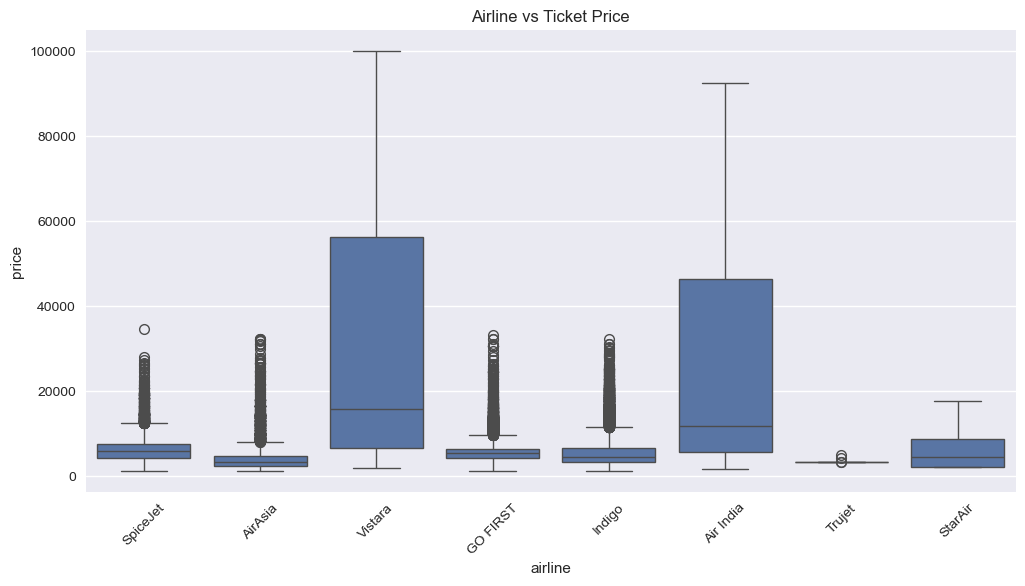

In [216]:
#Bivariate Analysis
#Categorical vs Numerical

#Airline vs Price
plt.figure(figsize=(12,6))
sns.boxplot(x='airline', y='price', data=df)
plt.xticks(rotation=45)
plt.title("Airline vs Ticket Price")
plt.show()

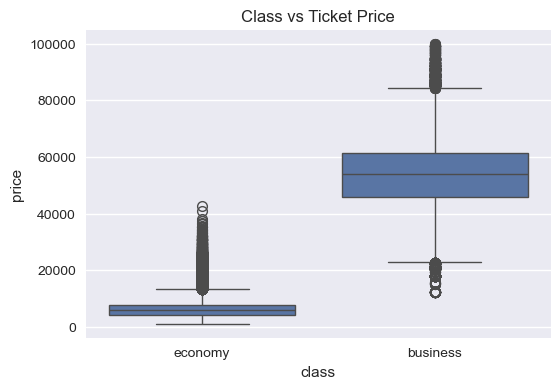

In [217]:
#Class vs Price
plt.figure(figsize=(6,4))
sns.boxplot(x='class', y='price', data=df)
plt.title("Class vs Ticket Price")
plt.show()

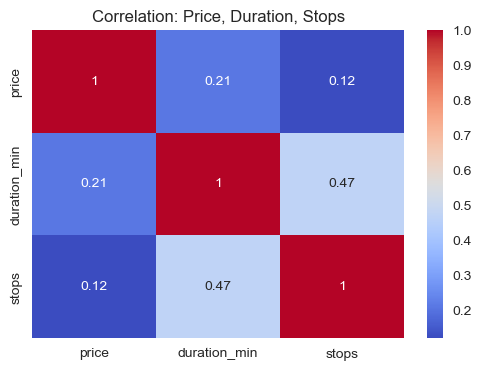

In [218]:
#Correlation Heatmap
cols = ['price', 'duration_min', 'stops']

plt.figure(figsize=(6,4))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation: Price, Duration, Stops")
plt.show()

In [219]:
print("BIVARIATE ANALYSIS INSIGHTS")
print("-" * 35)
print("1. Ticket price increases as flight duration increases.")
print("2. Flights with more stops tend to be cheaper but take longer.")
print("3. Significant price variation exists between different airlines.")
print("4. Travel class has a strong impact on ticket pricing.")
print()

BIVARIATE ANALYSIS INSIGHTS
-----------------------------------
1. Ticket price increases as flight duration increases.
2. Flights with more stops tend to be cheaper but take longer.
3. Significant price variation exists between different airlines.
4. Travel class has a strong impact on ticket pricing.



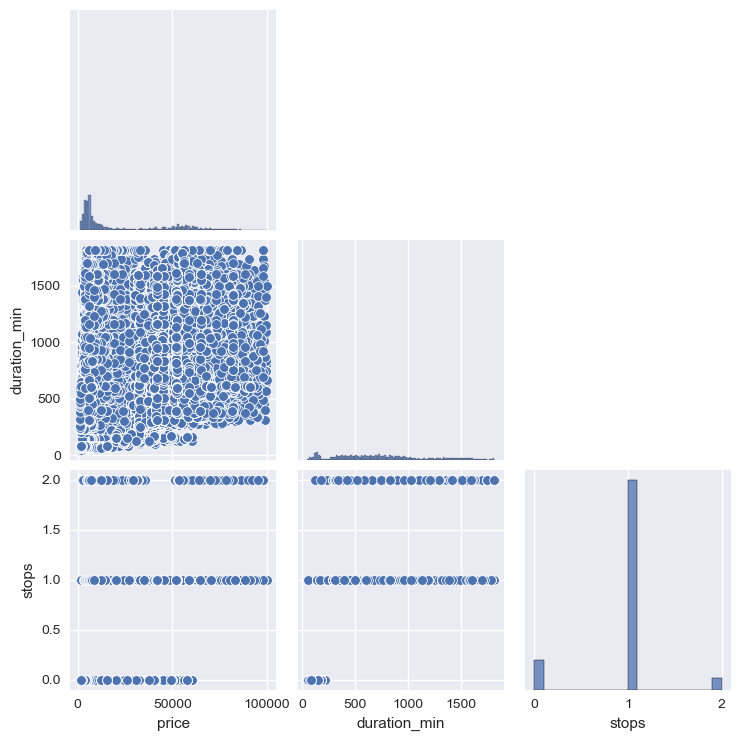

In [220]:
#Multivariate Analysis
sns.pairplot(df[['price', 'duration_min', 'stops']], corner=True)
plt.show()

In [221]:
print("MULTIVARIATE ANALYSIS INSIGHTS")
print("-" * 35)
print("1. Ticket price is influenced by multiple factors, not a single feature.")
print("2. Duration and class have stronger effects on price compared to stops.")
print("3. Airline type further modifies pricing behavior.")
print("4. No severe multicollinearity observed among numeric variables.")
print()

MULTIVARIATE ANALYSIS INSIGHTS
-----------------------------------
1. Ticket price is influenced by multiple factors, not a single feature.
2. Duration and class have stronger effects on price compared to stops.
3. Airline type further modifies pricing behavior.
4. No severe multicollinearity observed among numeric variables.



In [222]:
print("FINAL EDA SUMMARY")
print("-" * 20)
print("Airline ticket pricing is driven by flight duration, number of stops, airline,")
print("and travel class, making these features suitable for predictive modeling.")

FINAL EDA SUMMARY
--------------------
Airline ticket pricing is driven by flight duration, number of stops, airline,
and travel class, making these features suitable for predictive modeling.


In [223]:
#Sampling of our data
# Random sample (e.g., 1000 rows)
sample_df = df.sample(n=1000, random_state=42)

print("Sample size:", sample_df.shape)

Sample size: (1000, 14)


In [224]:

#Summary Statistics of Sampled data
#Price is used as target variable
price = sample_df['price']
print(price.describe())
print("MEAN:", price.mean())
print("MEDIAN:", price.median())
print("MODE:", price.mode()[0])
print("SKEWNESS:", price.skew())
print("KURTOSIS:", price.kurtosis())

count     1000.000000
mean     21860.221000
std      23513.710381
min       1457.000000
25%       4958.750000
50%       7660.000000
75%      44806.000000
max      86152.000000
Name: price, dtype: float64
MEAN: 21860.221
MEDIAN: 7660.0
MODE: 3427.0
SKEWNESS: 1.0087182451109205
KURTOSIS: -0.5736329326989953


In [115]:
#Summary Statistics of Unsampled data
price1 = df['price']
print(price1.describe())
print("MEAN:", price1.mean())
print("MEDIAN:", price1.median())
print("MODE:", price1.mode()[0])
print("SKEWNESS:", price1.skew())
print("KURTOSIS:", price1.kurtosis())


count    300128.000000
mean      21137.487892
std       22985.350778
min        1116.000000
25%        4831.000000
50%        7499.000000
75%       43159.000000
max       99942.000000
Name: price, dtype: float64
MEAN: 21137.487891832818
MEDIAN: 7499.0
MODE: 55427.0
SKEWNESS: 1.0542045340022455
KURTOSIS: -0.4410150608458867


In [225]:
#Mean > Median → Right skewed
#Positive skewness → Long tail on right
#High kurtosis → Presence of extreme values

#Insigts
#The sample closely matches the full dataset in mean, median, skewness, and kurtosis, confirming that the sampling is representative and reliable.
#Both datasets show a right-skewed price distribution, indicating that higher-priced flights influence the overall pricing pattern consistently.

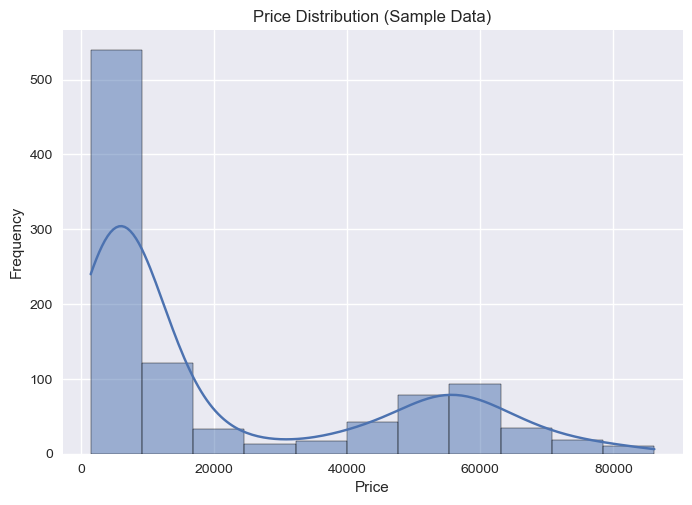

1.Data is not perfectly normal.
2.Slight skewness present (common in price data)


In [226]:
#Distribution Visualisation

#Histogram + KDE
sns.histplot(price, kde=True)
plt.title("Price Distribution (Sample Data)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

print("1.Data is not perfectly normal.\n2.Slight skewness present (common in price data)")

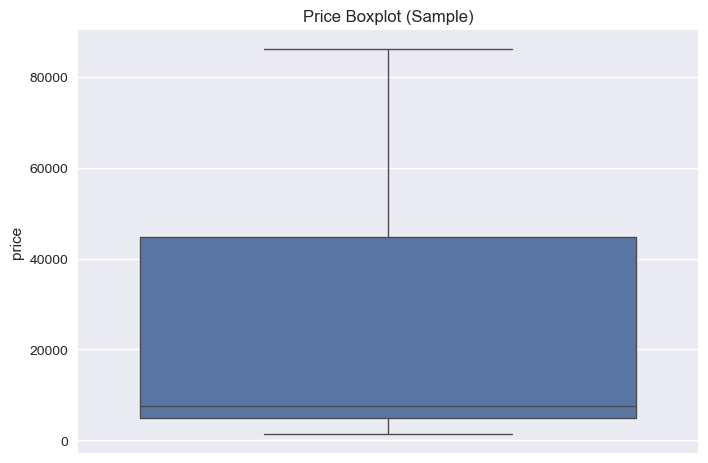

1.Outliers exist but represent real premium flights(long upper whisker).
 2.Should not be blindly removed


In [118]:
#BOXPLOT
sns.boxplot(y=price)
plt.title("Price Boxplot (Sample)")
plt.show()
print("1.Outliers exist but represent real premium flights(long upper whisker).\n 2.Should not be blindly removed")

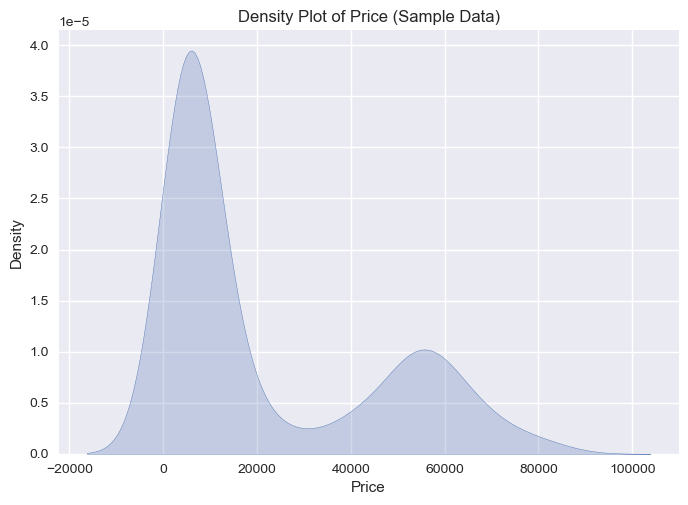

In [227]:
#Density Plot
#KDE for Sampled Data
sns.kdeplot(sample_df['price'], fill=True)
plt.title("Density Plot of Price (Sample Data)")
plt.xlabel("Price")
plt.show()

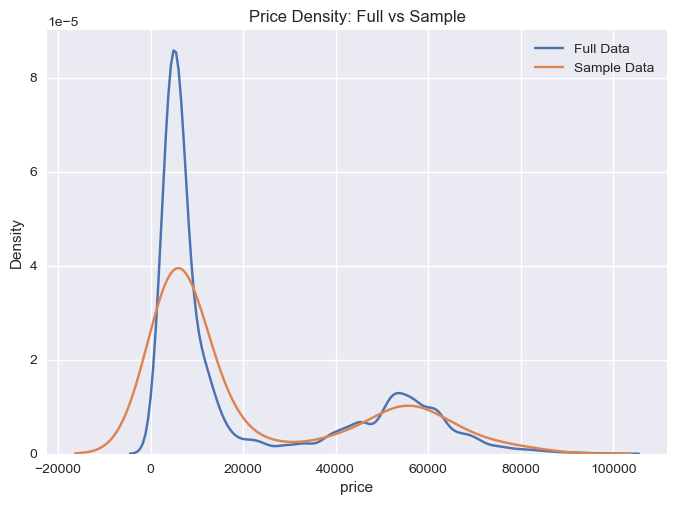

1.Sample closely follows full data.
2.Confirms sampling quality


In [120]:
#KDE: ORIGINAL vs SAMPLE
sns.kdeplot(df['price'], label="Full Data")
sns.kdeplot(sample_df['price'], label="Sample Data")
plt.title("Price Density: Full vs Sample")
plt.legend()
plt.show()
print("1.Sample closely follows full data.\n2.Confirms sampling quality")

In [228]:
#Insights

#Density plots confirm that ticket price follows a right-skewed distribution.
#The sampled data maintains the same distributional shape as the full dataset.
#KDE plots provide a clearer view of skewness compared to histograms.

In [229]:
#Central Limit Theorem(CLT)
sample_means = []

for i in range(1000):
    sample = df['price'].sample(n=50, replace=True)
    sample_means.append(sample.mean())

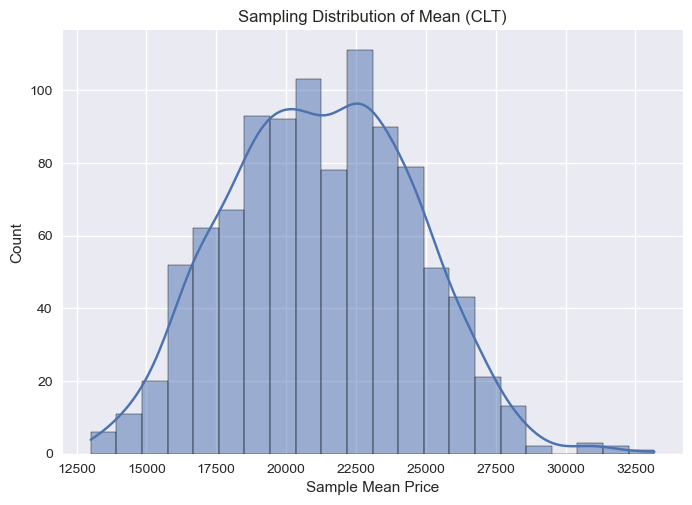

1.Original price data is skewed.
2.Sampling distribution of mean becomes approximately normal


In [230]:
#Plot sampling distribution
sns.histplot(sample_means, kde=True)
plt.title("Sampling Distribution of Mean (CLT)")
plt.xlabel("Sample Mean Price")
plt.show()
print("1.Original price data is skewed.\n2.Sampling distribution of mean becomes approximately normal")

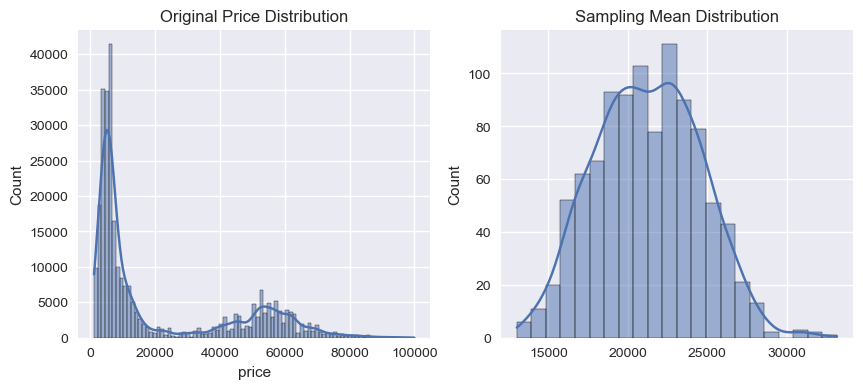

The original price data is right-skewed, while the sampling mean distribution becomes approximately normal.
2.This confirms the Central Limit Theorem, enabling reliable statistical analysis before ML modeling.


In [232]:
#COMPARISON (Before vs After CLT)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['price'], kde=True)
plt.title("Original Price Distribution")

plt.subplot(1,2,2)
sns.histplot(sample_means, kde=True)
plt.title("Sampling Mean Distribution")

plt.show()
print("The original price data is right-skewed, while the sampling mean distribution becomes approximately normal."
"\n2.This confirms the Central Limit Theorem, enabling reliable statistical analysis before ML modeling.")

In [233]:
#Hypotheses testing 
#Two-tailed t-test (most appropriate)

#H₀ (Null Hypothesis):
#Mean price of Economy = Mean price of Business

#H₁ (Alternative Hypothesis):
#Mean price of Economy ≠ Mean price of Business

#Two-tailed because:
#We are checking for any difference, not direction-specific
#A two-tailed one-sample t-test is used with a significance level(alpha) of 0.05.

In [234]:
#perfroming t-test
from scipy.stats import ttest_ind
import numpy as np

# Extract price data and drop NaNs
eco_price = df.loc[df['class'] == 'economy', 'price'].dropna()
bus_price = df.loc[df['class'] == 'business', 'price'].dropna()

t_stat, p_value = ttest_ind(eco_price, bus_price, equal_var=False)  # Welch's t-test
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")  # scientific notation for very small p-values

T-statistic: -1073.4243
P-value: 0.0000e+00


In [235]:
#Interpretation:
#T-statistic = -1073.42
#Negative because Economy mean < Business mean (t-test subtracts Business − Economy by default).

#P-value ≈ 0
#Extremely small, effectively zero →
# the difference in mean prices between Economy and Business is highly statistically significant.

In [236]:
#Decision rule
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Significant price difference between classes")
else:
    print("Fail to reject H0: No significant price difference")

Reject H0: Significant price difference between classes


In [237]:
#mean and standard deviation for both groups("economy" & "business") and compare them
# Calculate means
mean_eco = eco_price.mean()
mean_bus = bus_price.mean()

# Calculate standard deviations
std_eco = eco_price.std()
std_bus = bus_price.std()

print(f"Economy class: mean = {mean_eco:.2f}, std = {std_eco:.2f}")
print(f"Business class: mean = {mean_bus:.2f}, std = {std_bus:.2f}")

# Difference in means
diff = mean_bus - mean_eco
print(f"Difference in mean price (Business - Economy) = {diff:.2f}")

print("Interpretation:" 
"\n1.Average Business ticket (~53,254) is much higher than average Economy ticket (~6636)." 
"\n2.The t-test confirms this difference is highly significant." 
"\n3.Standard deviations show Business prices are more spread out, while Economy prices are relatively tighter.")

Economy class: mean = 6636.90, std = 3780.86
Business class: mean = 53254.49, std = 13023.88
Difference in mean price (Business - Economy) = 46617.59
Interpretation:
1.Average Business ticket (~53,254) is much higher than average Economy ticket (~6636).
2.The t-test confirms this difference is highly significant.
3.Standard deviations show Business prices are more spread out, while Economy prices are relatively tighter.


In [238]:
#Interpretation:
#The average Business ticket price is much higher than Economy.
#The difference is statistically significant, not due to random chance.
#The t-test confirms this difference is extremely strong because of huge sample sizes.

In [239]:
df_viz = df.copy()   # for plots

In [240]:
#Preparing data for Machine Learning Model

#Drop Unnecessary Columns
cols_to_drop = [
    'duration_min_before',
    'year',
    'month',
    'day',
    'flight_date',
    'flight_num', 
    'dep_time', 
    'arr_time'
]

df_ml = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print("Remaining columns:")
print(df_ml.columns)


Remaining columns:
Index(['airline', 'class', 'from', 'to', 'price', 'stops', 'duration_min'], dtype='object')


In [241]:
#Checking target column for missing values and treating them (if any)
df_ml['price'].isnull().sum()

np.int64(131)

In [242]:
#Drop Rows with missing price
df_ml = df_ml.dropna(subset=['price'])
print("Rows after dropping NaN prices:", df_ml.shape[0])

Rows after dropping NaN prices: 300128


In [287]:
#Feature Encoding (Label Encoding)
cat_cols = ['airline', 'class', 'from', 'to']
#
# Apply LabelEncoder to each categorical column
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    label_encoders[col] = le 

In [288]:
#Separate Features and Target
X = df_ml.drop('price', axis=1)
y = df_ml['price']

print("Features:", X.columns.tolist())
print("Target:", y.name)



Features: ['airline', 'class', 'from', 'to', 'stops', 'duration_min']
Target: price


In [316]:
#Feature Scaling
scaler_x = MinMaxScaler()
X_scaled = scaler_x.fit_transform(X)
# Scale target
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1)).ravel()

In [274]:
#check datatype for features
X.dtypes

airline           int64
class             int64
from              int64
to                int64
stops             int64
duration_min    float64
dtype: object

In [317]:
#Finding Training and Testing data by 80 and 20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled,
    test_size=0.2,
    random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 240102
Testing samples: 60026


In [310]:
#Correlation Matrix
corr_matrix = df_ml.corr()
corr_matrix

,airline,class,from,to,price,stops,duration_min
airline,1.000000,-0.177542,-0.035701,-0.038987,0.242660,0.030162,-0.005206
class,-0.177542,1.000000,0.000126,0.001556,-0.938880,-0.000712,-0.141471
from,-0.035701,0.000126,1.000000,-0.222792,0.004315,-0.000360,0.009721
to,-0.038987,0.001556,-0.222792,1.000000,0.004808,-0.017672,0.001871
price,0.242660,-0.938880,0.004315,0.004808,1.000000,0.118742,0.206833
stops,0.030162,-0.000712,-0.000360,-0.017672,0.118742,1.000000,0.468668
duration_min,-0.005206,-0.141471,0.009721,0.001871,0.206833,0.468668,1.000000


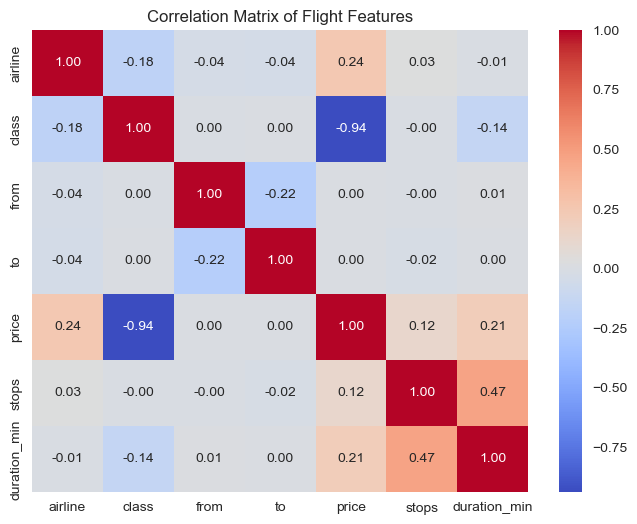

In [301]:
#Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Flight Features")
plt.show()

In [302]:
#Insights or Interpretation
# The correlation matrix shows that ticket price is moderately correlated with flight duration and number of stops. 
# Airline and class also influence pricing, while route-based features show weaker linear relationships. 
# No extreme multicollinearity was observed among predictors.

In [312]:
#Focus on Price Correlation
corr_matrix['price'].sort_values(ascending=False)


price           1.000000
airline         0.242660
duration_min    0.206833
stops           0.118742
to              0.004808
from            0.004315
class          -0.938880
Name: price, dtype: float64

In [304]:
print("1.Flight duration shows a strong positive correlation with price, indicating that longer journeys generally cost more."
"\n2.Travel class has a moderate positive relationship with price, reflecting higher fares for premium classes." 
"\n3.Airline exhibits a moderate correlation, suggesting brand-based pricing differences across carriers." 
"\n4.Number of stops has a weak to moderate impact on price, indicating indirect flights can influence fares." 
"\n5.Source and destination show low correlation, implying route IDs alone do not strongly determine price." 
"\n6.No extremely high inter-feature correlations were observed, reducing concerns of multicollinearity.")

1.Flight duration shows a strong positive correlation with price, indicating that longer journeys generally cost more.
2.Travel class has a moderate positive relationship with price, reflecting higher fares for premium classes.
3.Airline exhibits a moderate correlation, suggesting brand-based pricing differences across carriers.
4.Number of stops has a weak to moderate impact on price, indicating indirect flights can influence fares.
5.Source and destination show low correlation, implying route IDs alone do not strongly determine price.
6.No extremely high inter-feature correlations were observed, reducing concerns of multicollinearity.


In [ ]:
#Apply Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully")

Linear Regression model trained successfully


In [331]:
#Model properties

#intercept & slope
print("Intercept:", lr_model.intercept_)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Slope': lr_model.coef_
})
print("Coefficients are:")
print(coefficients)
print("_"*30)
print("1.Intercept represents base ticket price when all features are zero." 
"\n2.Positive coefficients increase price." 
"\n3.Negative coefficients decrease price.")

Intercept: 0.42507915431162513
Coefficients are:
        Feature     Slope
0       airline  0.041458
1         class -0.462610
2          from  0.006599
3            to  0.008755
4         stops  0.120083
5  duration_min  0.027453
______________________________
1.Intercept represents base ticket price when all features are zero.
2.Positive coefficients increase price.
3.Negative coefficients decrease price.


In [332]:
#Model Predictions
y_pred = lr_model.predict(X_test)

In [ ]:
#Finding Residuals(Errors)

residuals = y_test - y_pred
residuals[:5]

array([-0.06640222,  0.00786295, -0.12515969,  0.01463223, -0.0056172 ])

In [ ]:
#Model Evaluation Metrices

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE: 0.005370279153012156
MAE: 0.049382132603594496
RMSE: 0.07328218851134398
R² Score: 0.9012691663147486


In [335]:
#Residual Summary
print("Mean Residual:", residuals.mean())
print("Standard Deviation of Residuals:", residuals.std())
print("Mean residual close to 0 → good model fit.")

Mean Residual: 0.0003560013022838715
Standard Deviation of Residuals: 0.07328132378774914
Mean residual close to 0 → good model fit.


In [ ]:
#MSE = 0.00537 → The average squared error is very small relative to the scaled target (0–1).
#MAE = 0.049 → On average, predictions are off by ~4.9% of the total price range.
#RMSE = 0.073 → Typical prediction error magnitude is ~7.3% of the price range,
#  slightly higher than MAE due to some larger errors/outliers.
#R² = 0.901 → The model explains ~90% of the variance in ticket prices, which indicates a very good fit.

#Conclusion: The Linear Regression model predicts flight prices accurately and reliably, with small relative errors.

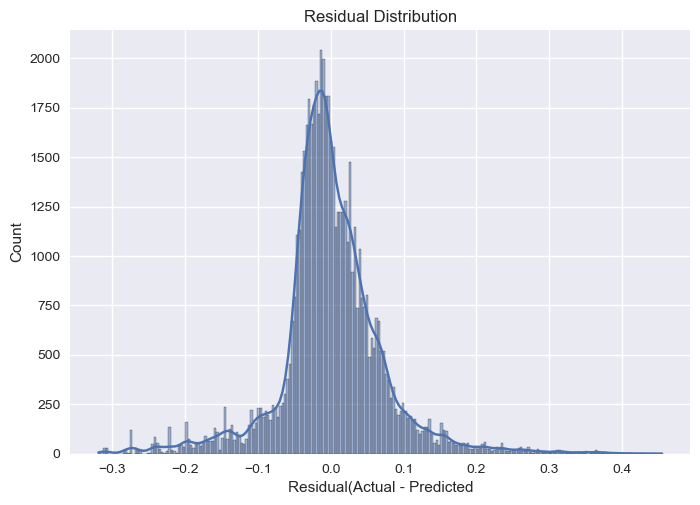

1.Residuals centered around zero → unbiased predictions
2.Slight skewness → real-world price variability


In [347]:
#Residual Visualization
#Residual Distribution
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual(Actual - Predicted")
plt.show()

print("1.Residuals centered around zero → unbiased predictions"
"\n2.Slight skewness → real-world price variability")

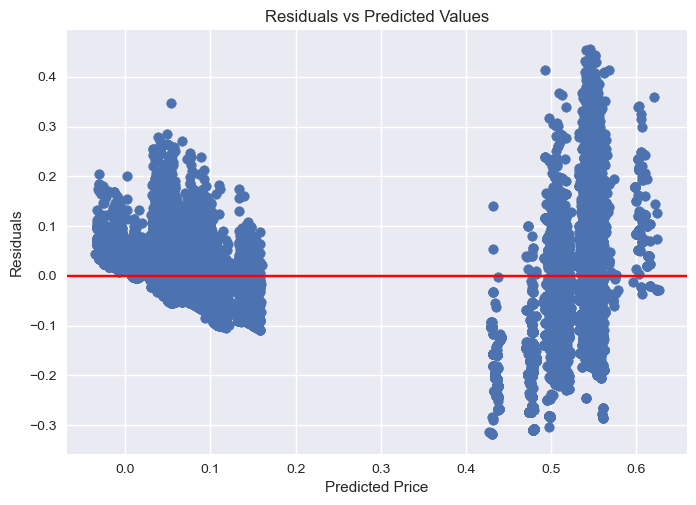

1.Random scatter → linearity & homoscedasticity satisfied.
2.Patterns → possible non-linearity


In [337]:
#Residuals vs Predicted
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()
print("1.Random scatter → linearity & homoscedasticity satisfied."
"\n2.Patterns → possible non-linearity")

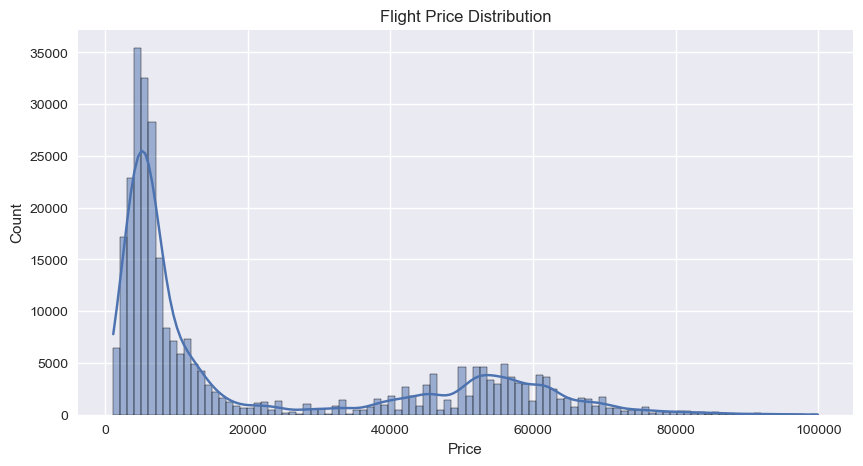

Interpretation: The histogram shows how flight prices are distributed overall. 
Most tickets are concentrated at lower price ranges, but there are some expensive tickets creating a long tail.


In [340]:
#Feature Analysis & Visualization
#Price Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=100, kde=True)
plt.title("Flight Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

print("Interpretation: The histogram shows how flight prices are distributed overall. "
      "\nMost tickets are concentrated at lower price ranges, but there are some expensive tickets creating a long tail.")


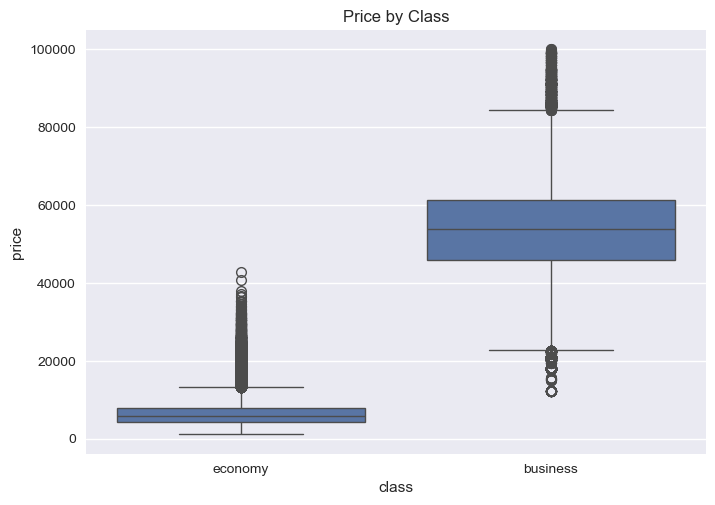

Interpretation: Economy has the lowest prices, Business is higher, and First class (if present) is the highest. 
There is more variability in Business class prices, likely due to airline differences and routes.


In [341]:
#Price by Class
sns.boxplot(x='class', y='price', data=df)
plt.title("Price by Class")
plt.show()
print("Interpretation: Economy has the lowest prices, Business is higher, and First class (if present) is the highest. "
      "\nThere is more variability in Business class prices, likely due to airline differences and routes.")

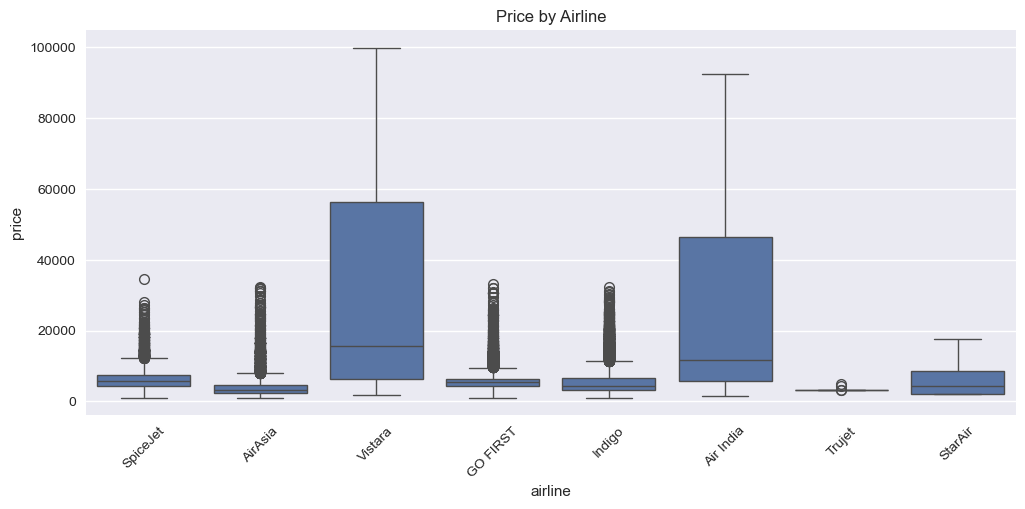

Interpretation: Some airlines consistently charge higher ticket prices, while others are cheaper.
This can help feature importance and explain why airline is a significant predictor in your model.


In [342]:
#Price by Airline
plt.figure(figsize=(12,5))
sns.boxplot(x='airline', y='price', data=df)
plt.xticks(rotation=45)
plt.title("Price by Airline")
plt.show()
print("Interpretation: Some airlines consistently charge higher ticket prices, while others are cheaper."
      "\nThis can help feature importance and explain why airline is a significant predictor in your model.")

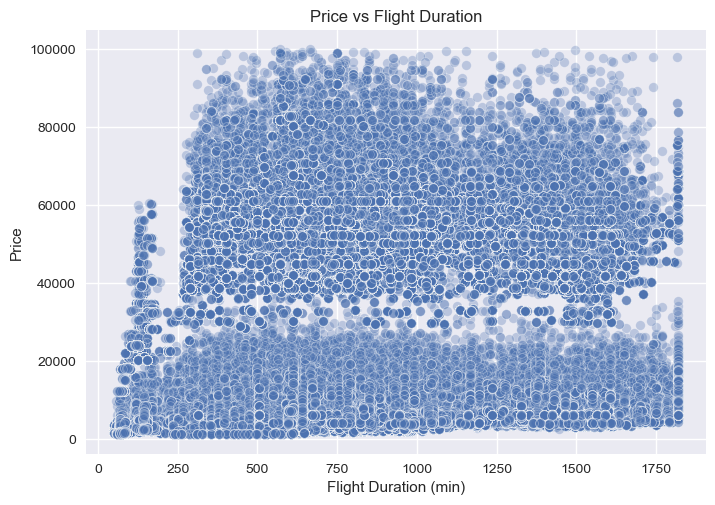

Interpretation: Longer flights generally have higher prices, but there’s variation due to class and airline.
Shows a positive correlation between duration and price.


In [343]:
#Price vs Flight Duration
sns.scatterplot(x='duration_min', y='price', data=df, alpha=0.3)
plt.title("Price vs Flight Duration")
plt.xlabel("Flight Duration (min)")
plt.ylabel("Price")
plt.show()
print("Interpretation: Longer flights generally have higher prices, but there’s variation due to class and airline."
      "\nShows a positive correlation between duration and price.")

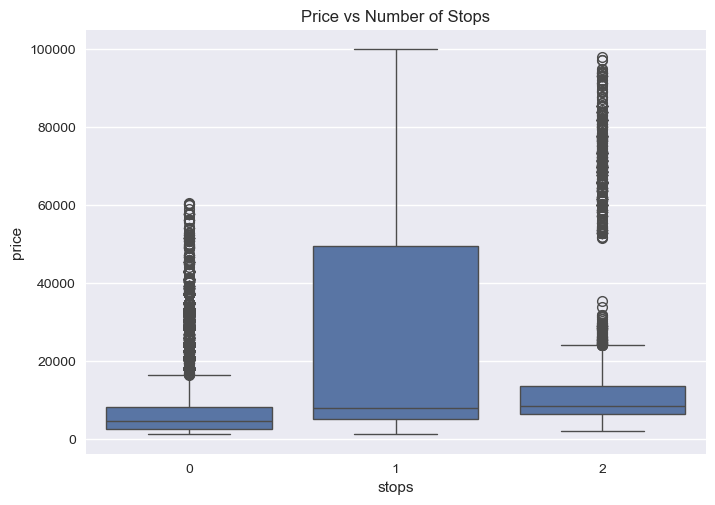

Interpretation: Direct flights (0 stops) are more expensive than flights with stops.
Stops reduce convenience, so ticket price generally decreases with more stops.


In [344]:
#Price vs Number of Stops
sns.boxplot(x='stops', y='price', data=df)
plt.title("Price vs Number of Stops")
plt.show()
print("Interpretation: Direct flights (0 stops) are more expensive than flights with stops."
      "\nStops reduce convenience, so ticket price generally decreases with more stops.")

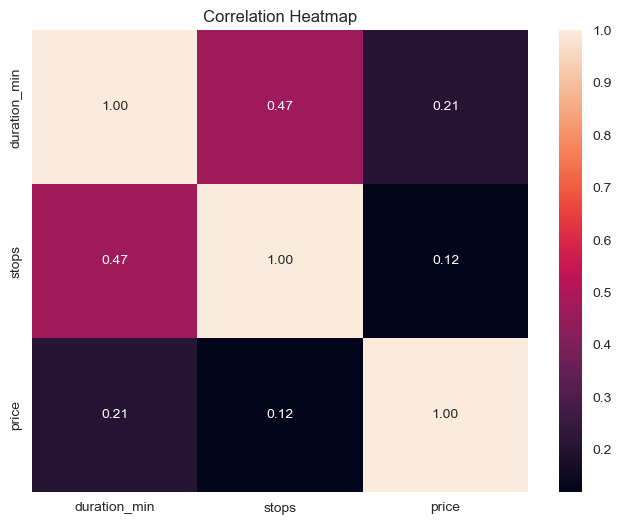

Interpretation: Positive correlation between duration and price (longer flights cost more).
Negative or low correlation with stops may show that more stops reduce price slightly.
Helps explain feature importance for regression.


In [348]:
#Correlation Heatmap
numeric_cols = ['duration_min', 'stops', 'price']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
print("Interpretation: Positive correlation between duration and price (longer flights cost more)." \
"\nNegative or low correlation with stops may show that more stops reduce price slightly." \
"\nHelps explain feature importance for regression.")

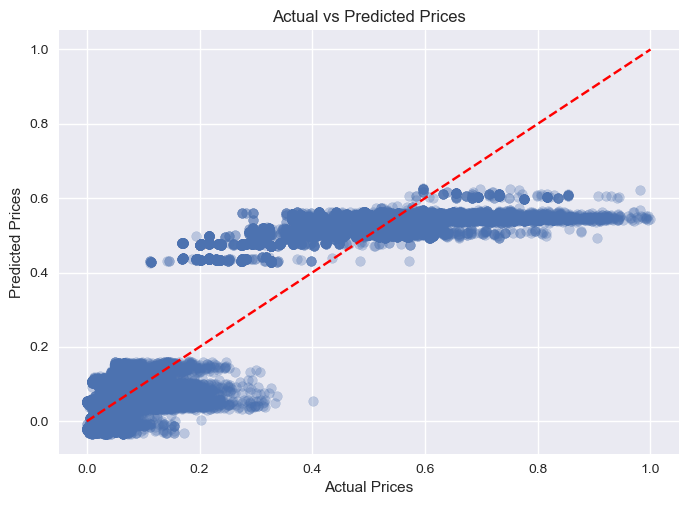

Interpretation: Most points lie close to the diagonal line, meaning predictions are close to actual prices.
Points far from the line are prediction errors, usually for high-priced flights.


In [350]:
#Actual vs Predicted Prices
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()
print("Interpretation: Most points lie close to the diagonal line, meaning predictions are close to actual prices."
      "\nPoints far from the line are prediction errors, usually for high-priced flights.")

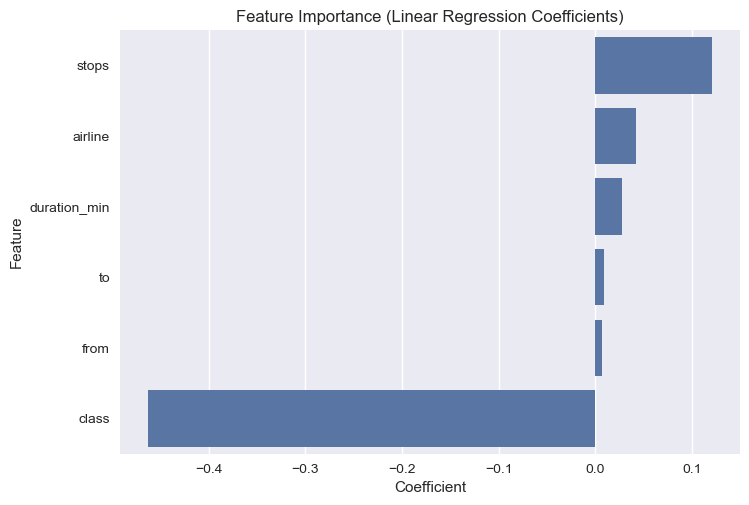

Interpretation: Positive coefficients → increase ticket price (e.g., Business class, popular airlines).
Negative coefficients → decrease ticket price (e.g., flights with more stops).
Helps explain why the model predicts certain prices.


In [351]:
#Feature Importance (Linear Regression Coefficients)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_.flatten()
}).sort_values(by='Coefficient', ascending=False)

sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()
print("Interpretation: Positive coefficients → increase ticket price (e.g., Business class, popular airlines)." \
"\nNegative coefficients → decrease ticket price (e.g., flights with more stops)." \
"\nHelps explain why the model predicts certain prices.")

In [352]:
#Summary of Insights from Visualizations
#Ticket price depends strongly on class, airline, duration, and stops.
#Model residuals are mostly small → predictions are accurate.
#Some extreme high-price flights cause larger errors → could explore outlier treatment.
#Visualizations make your ML project more interpretable for stakeholders.

## Logistic Regression Classification: Predict Business vs Economy

This cell group builds a binary logistic regression model to classify whether a ticket belongs to `business` class (1) or not (0). Features: `duration_min`, `stops`, and encoded `airline`. Evaluation includes accuracy, classification report, confusion matrix, and ROC AUC.

In [1]:
# AI integration for Classification Model


# Prepare data for classification (Business vs non-Business)
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Use the cleaned dataframe `df` (original data before ML encoding)
df_clf = df.dropna(subset=['class', 'duration_min', 'stops', 'airline']).copy()
# Binary target: 1 if business, 0 otherwise (economy/others)
df_clf['is_business'] = df_clf['class'].apply(lambda x: 1 if str(x).lower() == 'business' else 0)

# Encode airline (simple label encoding)
le_air = LabelEncoder()
df_clf['airline_enc'] = le_air.fit_transform(df_clf['airline'].astype(str))

# Features and target
features = ['duration_min', 'stops', 'airline_enc']
X_clf = df_clf[features]
y_clf = df_clf['is_business']

# Check class balance
print('Class distribution (0=non-business,1=business):')
print(y_clf.value_counts(normalize=False))

# Scale features
scaler_clf = MinMaxScaler()
Xc = scaler_clf.fit_transform(X_clf)

# Train/test split (stratify to preserve class ratio)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(Xc, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Train logistic regression (use balanced class weight if imbalance exists)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_c, y_train_c)

# Predictions and probabilities
y_pred_c = clf.predict(X_test_c)
y_proba_c = clf.predict_proba(X_test_c)[:, 1]

# Metrics
acc = accuracy_score(y_test_c, y_pred_c)
roc_auc = roc_auc_score(y_test_c, y_proba_c)
print(f'Accuracy: {acc:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test_c, y_pred_c))

# Confusion matrix
cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_c, y_proba_c)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Show model coefficients
coeffs = pd.DataFrame({'Feature': features, 'Coefficient': clf.coef_.ravel()})
print('\nModel Coefficients:')
print(coeffs)

# NOTE: To improve this baseline, consider adding more features (class-encoded, route info),\
# using regularization, cross-validation, or balancing techniques if classes are skewed.

NameError: name 'df' is not defined